In [1]:
import geokit as gk
import numpy as np
from os.path import join, isdir
from os import mkdir
from multiprocessing import Pool
from datetime import datetime as dt
from collections import namedtuple, OrderedDict
from json import dumps
from pathlib import Path
import matplotlib.pyplot as plt
import os

---

### run use priors

In [ ]:
# test_ExclusionCalculator_excludePrior() funktioniert - das excludieren von priors funktioniert -> es sind nur keine hinterlegt
priorSample = gl._test_data_["roads_prior_clip.tif"]
p = PriorSource(priorSample)    #loads prior dataset (tif file) # aachen roads


ec = gl.ExclusionCalculator(aachenShape)
ec.excludePrior(pr, value=(400, None))      #prior excludieren mit em wert 400?

___

In [7]:
#check values tif file
test = gk.raster.loadRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/clc-aachen_clipped.tif")
arr = gk.raster.extractMatrix(test)

In [8]:
arr

array([[20, 20, 20, ..., 12, 23, 23],
       [20, 20, 20, ..., 12, 23, 23],
       [20, 20, 20, ..., 12, 23, 23],
       ...,
       [25, 41, 41, ..., 24, 24, 24],
       [25, 41, 41, ..., 24, 24, 24],
       [41, 41, 41, ..., 25, 24, 24]], dtype=uint8)

In [9]:
# Print min, max, mean
print("Min:", np.min(arr))
print("Max:", np.max(arr))
print("Mean:", np.mean(arr))

Min: 1
Max: 41
Mean: 16.140258473667547


In [16]:
reg = gk.RegionMask.load(region=shape_file, where="SITENAME='Kermeter'", padExtent=max(distances)) 

/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.wa

Memory useage during calc: 168.37109375 MB


AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7fe7aa251c00>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fe7aa214f10>)

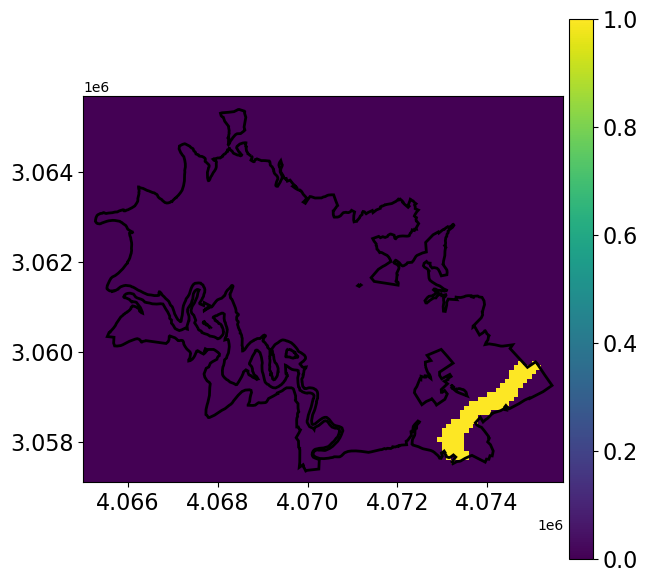

In [18]:
matrix = reg.indicateValues(
    source=tif_file_elevation,
    value=(0, 3)) > 0.5

reg.drawImage(matrix, figsize=(6, 6))

# plot

In [45]:
reg = gk.RegionMask.load(region="/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/input/Natura2000_aachenClipped.shp", where="SITENAME='Kermeter'", padExtent=1000) 

/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.warn(
/fast/home/l-madeisky/.conda/envs/glaes/lib/python3.10/site-packages/geokit/core/srs.py:283: DeprecationWarning: SRSCOMMON.europe_m is deprecated and will be removed in a future release.             use SRSCOMMON.europe_laea instead.
  warnings.wa

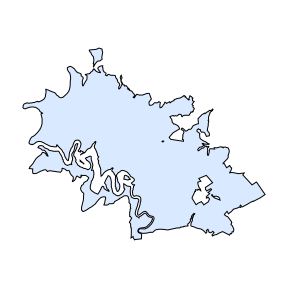

In [46]:
reg

In [47]:
example_data = np.ones_like(reg.mask)
reg.createRaster(data=example_data, output="/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/region_of_interest.tif")

'/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/region_of_interest.tif'

### from matrix

In [ ]:
region_df_clipped = gk.geom.polygonizeMatrix(matrix, bounds=reg.extent.xyXY, srs=reg.srs)
gk.geom.drawGeoms(region_df_clipped, figsize=(6, 6))

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f57cfc5e500>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f57cf55a230>)

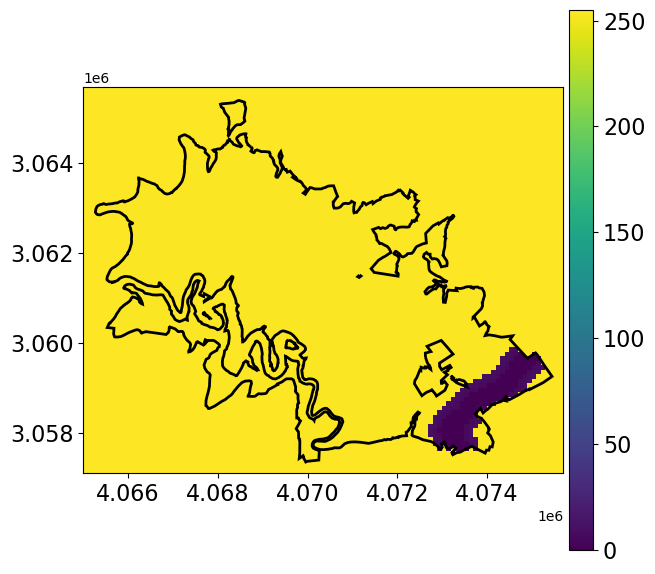

In [ ]:
### regionmask
reg.drawImage(result, figsize=(6, 6))

### raster

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f67e0320eb0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f67e0321270>)

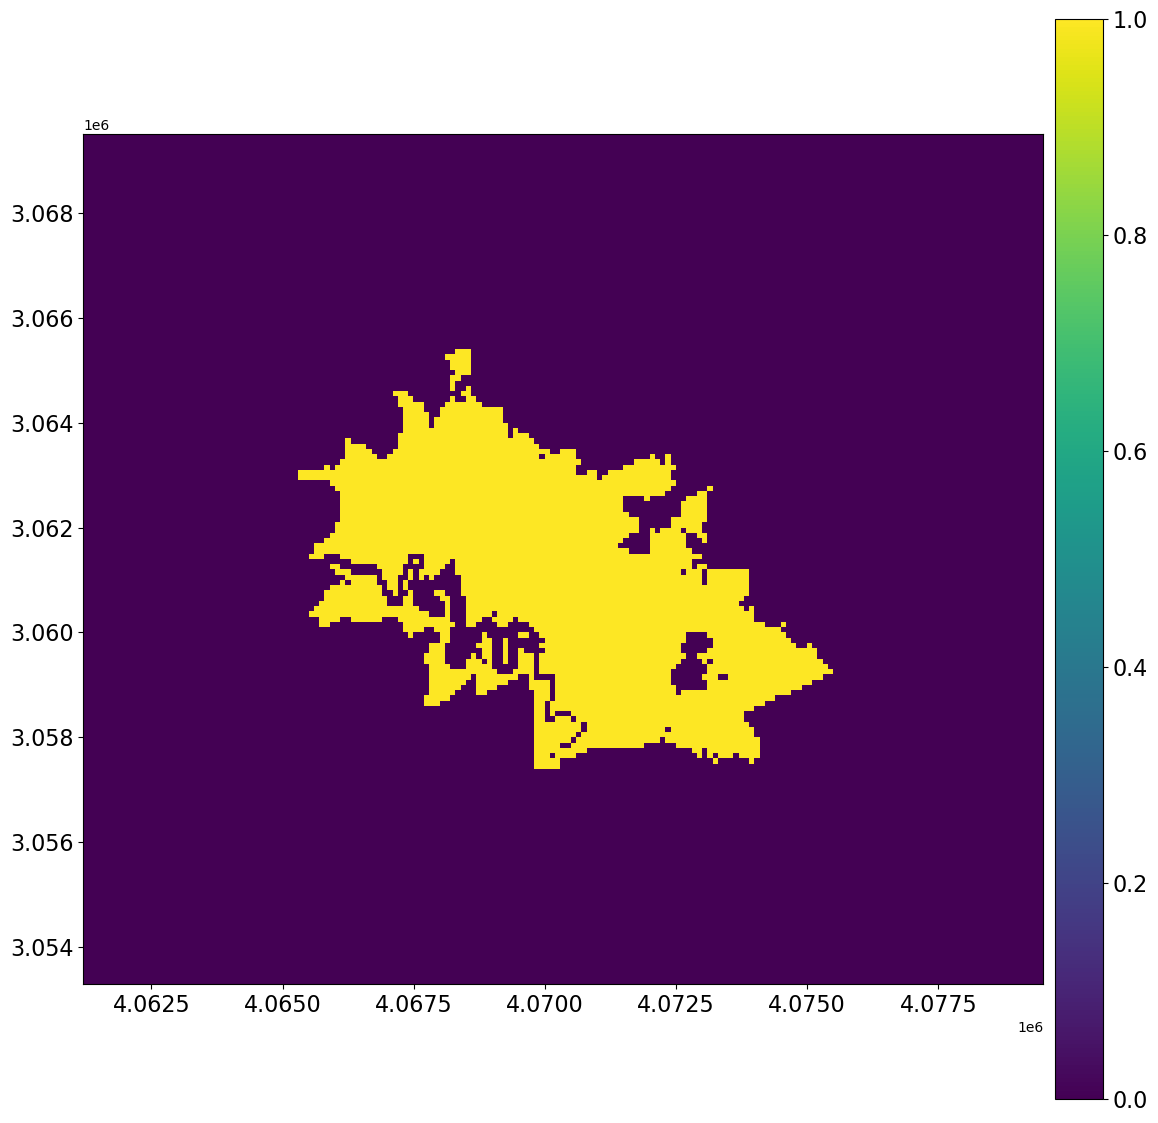

In [4]:
gk.drawRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/region_of_interest.tif")

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7f67e0431db0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f67e0432170>)

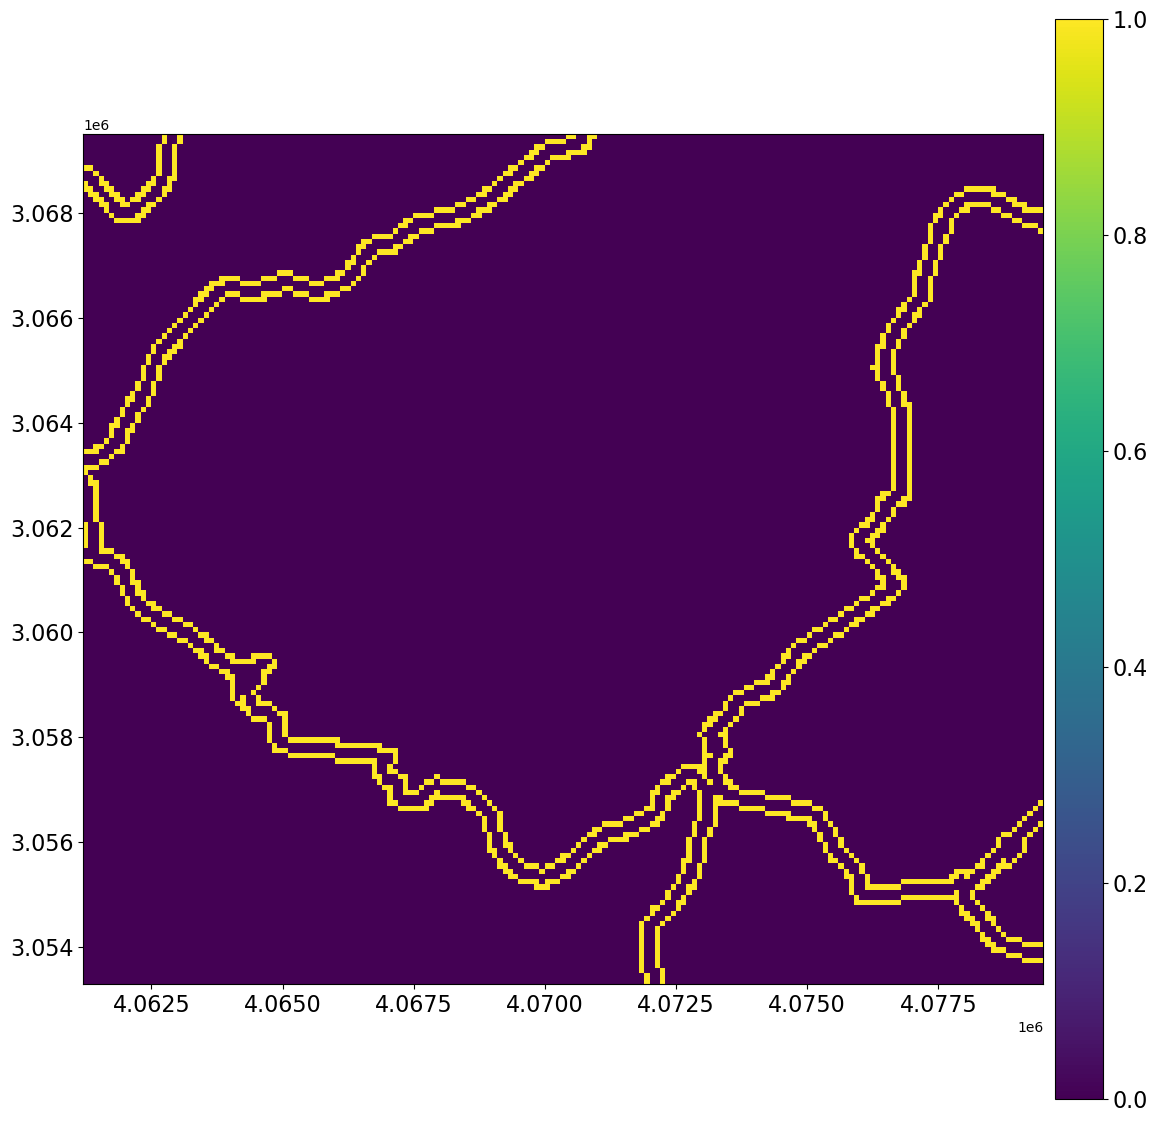

In [3]:
gk.drawRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/feature_of_interest.tif")

AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x7fea1ccd40a0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fea1ccd4490>)

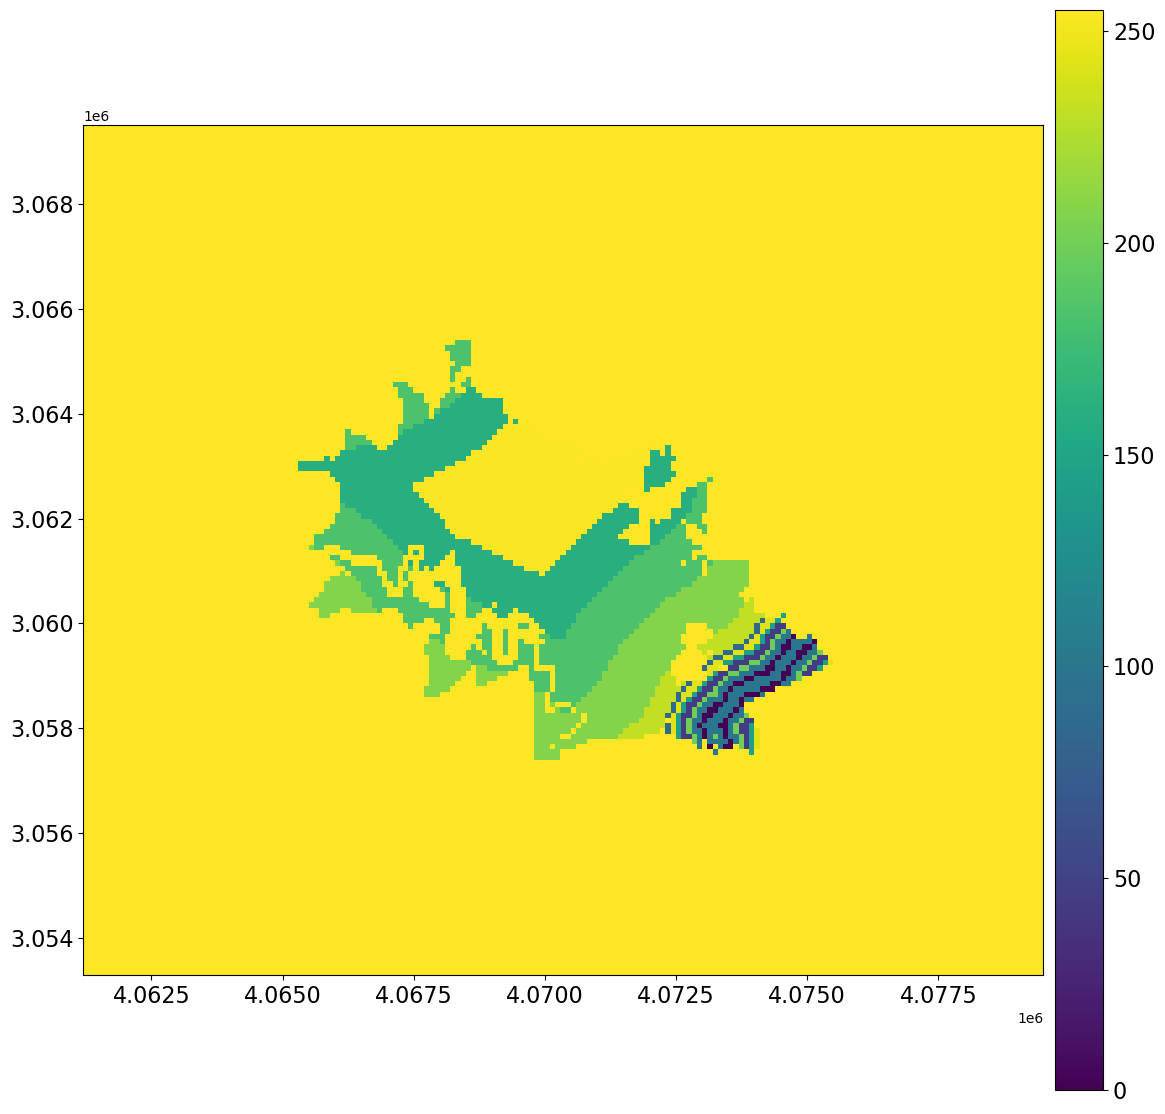

In [32]:
gk.drawRaster("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output/agriculture_proximity/agriculture_proximity.tif")

### shape

AxHands(ax=<Axes: >, handles=0      PathPatch5((6.38135, 50.6533) ...)
1      PathPatch9((6.37288, 50.6531) ...)
2      PathPatch9((6.38983, 50.6536) ...)
3       PathPatch17((6.5401, 50.651) ...)
4       PathPatch5((6.5407, 50.6429) ...)
                     ...                 
75    PathPatch17((6.47991, 50.5664) ...)
76     PathPatch5((6.47152, 50.5652) ...)
77    PathPatch45((6.48528, 50.5702) ...)
78      PathPatch5((6.49549, 50.566) ...)
79     PathPatch5((6.53215, 50.5671) ...)
Length: 80, dtype: object, cbar=None)

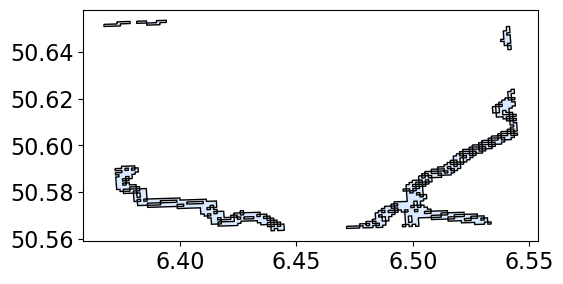

In [25]:

aachen = gk.vector.extractFeatures("/fast/home/l-madeisky/models_IEK_3/IEK3_Models/ethos-installation/ethos_suite_repositories/glaes/deletme_create_prior/output.test_1.shp")
gk.drawGeoms(aachen, figsize=(5, 5), srs=4326)